In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import pickle
import joblib


In [5]:
def build_lstm_model(input_shape):

    model = Sequential()
    
    # LSTM Layer 1
    model.add(LSTM(units=64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    
    # LSTM Layer 2
    model.add(LSTM(units=64, return_sequences=False))
    model.add(Dropout(0.2))
    
    # Dense Layer for output
    model.add(Dense(units=1))
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    return model

In [6]:
print("1. Loading preprocessed data from data_preprocessing notebook...")

with open('../data/preprocessed/preprocessed_data_lstm.pkl', 'rb') as f:
    data_dict = pickle.load(f)

X_train = data_dict['X_train']
y_train = data_dict['y_train']
X_val = data_dict['X_val']

y_val = data_dict['y_val']
X_test = data_dict['X_test']
y_test = data_dict['y_test']
df_long = data_dict['df_long']

print("Data loaded successfully!")
print(f"Train: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Val: X_val {X_val.shape}, y_val {y_val.shape}")
print(f"Test: X_test {X_test.shape}, y_test {y_test.shape}")

1. Loading preprocessed data from data_preprocessing notebook...
Data loaded successfully!
Train: X_train (77462, 96, 6), y_train (77462,)
Val: X_val (17411, 96, 6), y_val (17411,)
Test: X_test (17447, 96, 6), y_test (17447,)


In [7]:
# LSTM data must be scaled from 0 to 1 for the Neural Network to converge well.
print("2. Normalizing (Scaling) multivariate data to 0-1...")
scaler_x = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
    
feature_cols = ['Traffic_Volume', 'day_of_week', 'hour_of_day', 'is_weekend', 'is_rush_hour', 'is_night']
    
# We copy the real values to compare later if needed
df_long['Traffic_Volume_Original'] = df_long['Traffic_Volume']
    
# Fit scaler separately for y (column 0) for easy inverse_transform later
scaler_y.fit(df_long[['Traffic_Volume']])
    
# Scale all current features
df_long[feature_cols] = scaler_x.fit_transform(df_long[feature_cols])

2. Normalizing (Scaling) multivariate data to 0-1...


In [8]:
# Load sequences from pickle file (already created in data_preprocessing)
print("3. Loading LSTM sequences from preprocessed data...")

# Sequences are already in the pickle file
print(f"X_train size: {X_train.shape}")
print(f"y_train size: {y_train.shape}")
print(f"X_val size: {X_val.shape}")
print(f"y_val size: {y_val.shape}")
print(f"X_test size: {X_test.shape}")
print(f"y_test size: {y_test.shape}")

print("Sequences loaded successfully!")

3. Loading LSTM sequences from preprocessed data...
X_train size: (77462, 96, 6)
y_train size: (77462,)
X_val size: (17411, 96, 6)
y_val size: (17411,)
X_test size: (17447, 96, 6)
y_test size: (17447,)
Sequences loaded successfully!


In [9]:
print("\n5. Compile and Train LSTM...")
# input shape is (time_steps, features) specifically (96, 1)
model = build_lstm_model((X_train.shape[1], X_train.shape[2]))
model.summary()
    
# Early stop to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
# Training (limited to 20 epochs for quick debugging, can increase later)
history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=64,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        verbose=1
    )


5. Compile and Train LSTM...


c:\Users\Admin\Documents\COS30019-Group-7-Assignment2\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 96, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,265 (200.25 KB)

 Trainable params: 51,265 (200.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 158s 124ms/step - loss: 180745.9688 - val_loss: 153169.4688
Epoch 2/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 148s 122ms/step - loss: 138281.9375 - val_loss: 117359.7109
Epoch 3/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 140s 116ms/step - loss: 105609.1016 - val_loss: 89271.5469
Epoch 4/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 140s 116ms/step - loss: 79898.5625 - val_loss: 67270.1094
Epoch 5/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 136s 112ms/step - loss: 59766.4844 - val_loss: 50041.6016
Epoch 6/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 99s 81ms/step - loss: 44138.3164 - val_loss: 36436.7188
Epoch 7/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 95s 79ms/step - loss: 31944.6934 - val_loss: 26323.4551
Epoch 8/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 90s 74ms/step - loss: 22983.8965 - val_loss: 18897.1523
Epoch 9/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 90s 74ms/step - loss: 16583.8555 - val_loss: 13742.5352
Epoch 10/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 89s 74ms/step - loss: 12314.8330 - val_loss: 10421.8984



6. Plotting Training History (Loss) Chart....


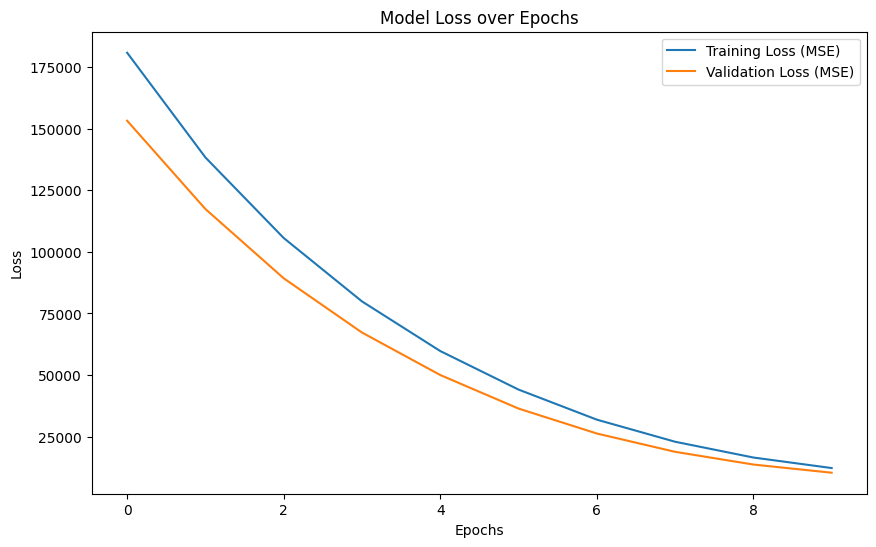

In [10]:
print("\n6. Plotting Training History (Loss) Chart....")
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


7. Evaluating Model on Test Set...
546/546 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - loss: 8615.9922
Test Loss (MSE - scaled format): 8615.9921875
546/546 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step


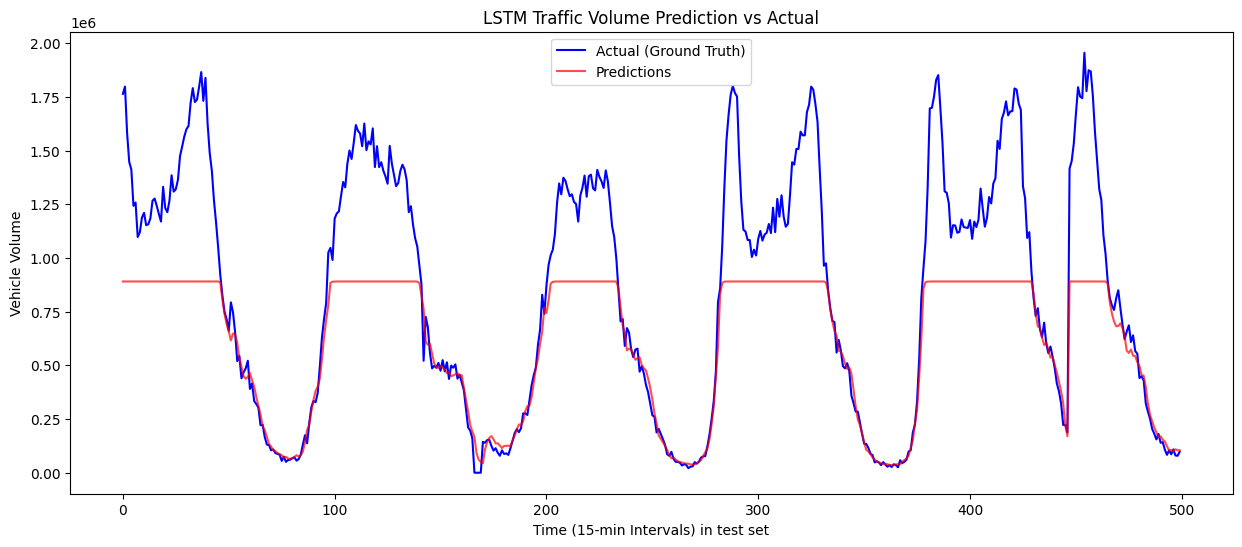

In [11]:
print("\n7. Evaluating Model on Test Set...")
test_loss = model.evaluate(X_test, y_test)
print(f"Test Loss (MSE - scaled format): {test_loss}")
    
# Predict on a segment of Test
predictions = model.predict(X_test)
    
# Inverse scale back to real numbers
predictions_denorm = scaler_y.inverse_transform(predictions)
y_test_denorm = scaler_y.inverse_transform(y_test.reshape(-1, 1))
    
# Plot some frames comparing prediction vs actual results
plt.figure(figsize=(15, 6))
# Show first 500 data points in Test for easy viewing
plt.plot(y_test_denorm[:500], label='Actual (Ground Truth)', color='blue')
plt.plot(predictions_denorm[:500], label='Predictions', color='red', alpha=0.7)
plt.title('LSTM Traffic Volume Prediction vs Actual')
plt.xlabel('Time (15-min Intervals) in test set')
plt.ylabel('Vehicle Volume')
plt.legend()
plt.show()

In [ ]:
model.save('../models/lstm/lstm_traffic_model.keras')
print("LSTM model saved successfully!")

LSTM model saved successfully!


NameError: name 'scaler' is not defined